# Walmart Store Sales — Prophet v5: clean promotion/context features

v4 is the current champion: event-aware Thanksgiving/Christmas windows improved the fixed 50/50 seasonal-naive + Prophet blend to `1367.45` WMAE.

v5 preserves that successful backbone and adds a larger, leakage-safe feature set from `features.csv`:

```text
MarkdownLogTotal       = log1p(sum(MarkDown1...MarkDown5))
HasMarkdown            = whether any Markdown value is supplied for that Store-Date
TemperatureDeviation13 = current temperature - trailing 13-week store average
FuelPriceChange4       = current fuel price - four weeks earlier
UnemploymentChange4    = current unemployment - four weeks earlier
```

All values are known for the Kaggle forecast dates. Markdown missingness is filled with `0` only as an explicit no-Markdown state; no `bfill()` or future-to-past feature propagation is used.

Model changes are deliberately conservative: the event-aware calendar stays, but Prophet uses a more regularized yearly/trend configuration and weak regressor priors. The final forecast stays a fixed 50/50 blend with 52-week seasonal naive.


In [2]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"


In [3]:
from __future__ import annotations

import json
import logging
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

pd.set_option("display.max_columns", 120)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "wandb": wandb.__version__,
})


{'python': '3.12.13', 'pandas': '2.2.2', 'numpy': '2.0.2', 'wandb': '0.28.0'}


In [1]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Mounted at /content/drive


## Configuration

v5 changes feature engineering and regularization together, while retaining the v4 event-aware holiday representation and the fixed 50/50 blend. The added regressors are intentionally few and weakly regularized because each Prophet model has limited per-series history.

In [4]:
SEED = 42
np.random.seed(SEED)

HOLIDAY_WINDOWS_DAYS = {
    "super_bowl": (0, 0),
    "labor_day": (0, 0),
    "thanksgiving": (-7, 0),
    "christmas": (-7, 0),
}
COVARIATE_COLUMNS = [
    "MarkdownLogTotal",
    "HasMarkdown",
    "TemperatureDeviation13",
    "FuelPriceChange4",
    "UnemploymentChange4",
]

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "holiday_weight": 5.0,
    "top_n_series": None,
    "min_history_points": 52,
    "seasonal_lag_weeks": 52,
    "prophet_blend_weight": 0.50,
    "holiday_windows_days": HOLIDAY_WINDOWS_DAYS,
    "covariate_columns": COVARIATE_COLUMNS,
    "growth": "linear",
    "yearly_seasonality": 8,
    "weekly_seasonality": False,
    "daily_seasonality": False,
    "seasonality_mode": "additive",
    "changepoint_prior_scale": 0.03,
    "seasonality_prior_scale": 5.0,
    "holidays_prior_scale": 15.0,
    "regressor_prior_scale": 0.15,
    "interval_width": 0.80,
    "prediction_clip_min": 0.0,
    "prediction_clip_max": 300000.0,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "prophet-experiments",
    "run_name": "prophet_v5_clean_covariates_regularized_calendar_all_series_validation",
    "artifact_name": "prophet-v5-clean-covariates-regularized-calendar-all-series-validation",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/prophet_v5_clean_covariates")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'holiday_weight': 5.0,
 'top_n_series': None,
 'min_history_points': 52,
 'seasonal_lag_weeks': 52,
 'prophet_blend_weight': 0.5,
 'holiday_windows_days': {'super_bowl': (0, 0),
  'labor_day': (0, 0),
  'thanksgiving': (-7, 0),
  'christmas': (-7, 0)},
 'covariate_columns': ['MarkdownLogTotal',
  'HasMarkdown',
  'TemperatureDeviation13',
  'FuelPriceChange4',
  'UnemploymentChange4'],
 'growth': 'linear',
 'yearly_seasonality': 8,
 'weekly_seasonality': False,
 'daily_seasonality': False,
 'seasonality_mode': 'additive',
 'changepoint_prior_scale': 0.03,
 'seasonality_prior_scale': 5.0,
 'holidays_prior_scale': 15.0,
 'regressor_prior_scale': 0.15,
 'interval_width': 0.8,
 'prediction_clip_min': 0.0,
 'prediction_clip_max': 300000.0,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'prophet-experiments',
 'run_name': 'prophet_v5_clean_covariates_regularized_calendar_all_series_valid

## Load data


In [5]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError({"data_dir": str(DATA_DIR), "missing_files": missing_files})

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing = {
    "train": sorted(required_train.difference(train_raw.columns)),
    "test": sorted(required_test.difference(test_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)
display(train_raw.head())


,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Split, all-series selection and clean known-future covariates

In [6]:
all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]
all_model_dates = pd.Index(sorted(set(all_train_dates).union(set(test_dates))), name="Date")

if len(test_dates) != CONFIG["validation_weeks"]:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG["min_history_points"]:
    raise ValueError("Not enough fit history for configured Prophet experiment.")

series_sales = (
    train_raw.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .sum()
    .sort_values("Weekly_Sales", ascending=False)
)
if CONFIG["top_n_series"] is None:
    top_series = series_sales[["Store", "Dept"]].copy()
else:
    top_series = series_sales.head(int(CONFIG["top_n_series"]))[["Store", "Dept"]].copy()

selected_keys = set(map(tuple, top_series[["Store", "Dept"]].to_numpy()))
selected_train = train_raw.merge(top_series.assign(_keep=1), on=["Store", "Dept"], how="inner").drop(columns="_keep")

required_feature_columns = {"Store", "Date", "Temperature", "Fuel_Price", "Unemployment", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"}
missing_feature_columns = sorted(required_feature_columns.difference(features_raw.columns))
if missing_feature_columns:
    raise ValueError({"missing_feature_columns": missing_feature_columns})

# `features.csv` supplies these values for both train and Kaggle test dates.
# No value is backfilled from a later date. Markdown missingness is a documented zero/no-promotion state.
store_covariates = features_raw[["Store", "Date", "Temperature", "Fuel_Price", "Unemployment", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]].copy()
store_covariates = store_covariates.drop_duplicates(["Store", "Date"]).sort_values(["Store", "Date"]).reset_index(drop=True)
for column in ["Temperature", "Fuel_Price", "Unemployment", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]:
    store_covariates[column] = pd.to_numeric(store_covariates[column], errors="coerce")

markdown_columns = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
store_covariates["HasMarkdown"] = store_covariates[markdown_columns].notna().any(axis=1).astype(np.int8)
store_covariates[markdown_columns] = store_covariates[markdown_columns].fillna(0.0)
store_covariates["MarkdownLogTotal"] = np.log1p(store_covariates[markdown_columns].sum(axis=1).clip(lower=0.0))

# Temperature is known at the forecast date; the trailing mean uses current and earlier feature rows only.
store_covariates["Temperature"] = store_covariates.groupby("Store")["Temperature"].transform(lambda s: s.ffill())
store_covariates["Temperature"] = store_covariates["Temperature"].fillna(store_covariates["Temperature"].median())
temp_trailing_mean = store_covariates.groupby("Store")["Temperature"].transform(lambda s: s.rolling(13, min_periods=1).mean())
store_covariates["TemperatureDeviation13"] = store_covariates["Temperature"] - temp_trailing_mean

for raw_column, feature_column in [("Fuel_Price", "FuelPriceChange4"), ("Unemployment", "UnemploymentChange4")]:
    store_covariates[raw_column] = store_covariates.groupby("Store")[raw_column].transform(lambda s: s.ffill())
    store_covariates[raw_column] = store_covariates[raw_column].fillna(store_covariates[raw_column].median())
    store_covariates[feature_column] = store_covariates.groupby("Store")[raw_column].transform(lambda s: s.diff(4)).fillna(0.0)

store_covariates = store_covariates[["Store", "Date", *CONFIG["covariate_columns"]]]
required_covariate_index = pd.MultiIndex.from_product(
    [sorted(store_covariates["Store"].unique()), all_model_dates], names=["Store", "Date"]
)
coverage = store_covariates.set_index(["Store", "Date"])[CONFIG["covariate_columns"]].reindex(required_covariate_index)
if coverage.isna().any().any():
    missing_count = int(coverage.isna().sum().sum())
    raise ValueError(f"Known-future covariate table has {missing_count} missing values after safe preprocessing.")

split_summary = {
    "validation_weeks": CONFIG["validation_weeks"],
    "fit_start": str(fit_dates.min().date()),
    "fit_end": str(fit_dates.max().date()),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "test_start": str(test_dates.min().date()),
    "test_end": str(test_dates.max().date()),
    "all_train_rows": int(len(train_raw)),
    "selected_train_rows": int(len(selected_train)),
    "top_n_series": CONFIG["top_n_series"],
    "selected_series": int(len(selected_keys)),
    "covariate_count": int(len(CONFIG["covariate_columns"])),
}
display(pd.Series(split_summary, name="value").to_frame())
display(store_covariates.head())

,value
validation_weeks,39
fit_start,2010-02-05
fit_end,2012-01-27
validation_start,2012-02-03
validation_end,2012-10-26
test_start,2012-11-02
test_end,2013-07-26
all_train_rows,421570
selected_train_rows,421570
top_n_series,None


,Store,Date,MarkdownLogTotal,HasMarkdown,TemperatureDeviation13,FuelPriceChange4,UnemploymentChange4
0,1,2010-02-05,0.0,0,0.000,0.000,0.0
1,1,2010-02-12,0.0,0,-1.900,0.000,0.0
2,1,2010-02-19,0.0,0,-0.320,0.000,0.0
3,1,2010-02-26,0.0,0,4.785,0.000,0.0
4,1,2010-03-05,0.0,0,3.724,0.053,0.0


## Metric, event-aware calendar and seasonal-naive reference

In [7]:
def wmae(y_true, y_pred, is_holiday, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def walmart_event_name(date: pd.Timestamp) -> str:
    month = pd.Timestamp(date).month
    if month == 2:
        return "super_bowl"
    if month == 9:
        return "labor_day"
    if month == 11:
        return "thanksgiving"
    if month == 12:
        return "christmas"
    return "other_walmart_holiday"


def make_event_holidays_frame(dates: pd.Series, is_holiday: pd.Series) -> pd.DataFrame:
    calendar = pd.DataFrame({"ds": pd.to_datetime(dates), "is_holiday": np.asarray(is_holiday, dtype=bool)})
    calendar = calendar.loc[calendar["is_holiday"], ["ds"]].drop_duplicates().copy()
    calendar["holiday"] = calendar["ds"].map(walmart_event_name)
    calendar[["lower_window", "upper_window"]] = calendar["holiday"].map(
        lambda name: HOLIDAY_WINDOWS_DAYS.get(name, (0, 0))
    ).apply(pd.Series)
    return calendar[["holiday", "ds", "lower_window", "upper_window"]].sort_values("ds").reset_index(drop=True)


def add_store_covariates(frame: pd.DataFrame, store: int) -> pd.DataFrame:
    frame = frame.copy()
    frame["Store"] = int(store)
    frame = frame.merge(
        store_covariates,
        left_on=["Store", "ds"],
        right_on=["Store", "Date"],
        how="left",
        validate="many_to_one",
    ).drop(columns="Date")
    if frame[CONFIG["covariate_columns"]].isna().any().any():
        raise ValueError(f"Missing known-future covariates for Store={store}")
    return frame


holiday_calendar = pd.concat([
    train_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
    test_raw[["Date", "IsHoliday"]].rename(columns={"Date": "ds"}),
], ignore_index=True).drop_duplicates("ds")
holidays_df = make_event_holidays_frame(holiday_calendar["ds"], holiday_calendar["IsHoliday"])

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

sales_panel = (
    selected_train.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(index=pd.MultiIndex.from_frame(top_series), columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

actual_val = sales_panel.loc[:, val_dates].to_numpy(dtype=float)
lag = CONFIG["seasonal_lag_weeks"]
seasonal_naive = sales_panel.loc[:, all_train_dates[-CONFIG["validation_weeks"] - lag:-lag]].to_numpy(dtype=float)
val_holidays_matrix = np.tile(holiday_by_date.loc[val_dates].to_numpy(dtype=bool), (sales_panel.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "selected_series": len(sales_panel),
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "holiday_event_counts": holidays_df["holiday"].value_counts().to_dict(),
    "covariates": CONFIG["covariate_columns"],
})
display(holidays_df)


{'selected_series': 3331, 'seasonal_naive_wmae': 1604.2696976819943, 'holiday_event_counts': {'super_bowl': 4, 'labor_day': 3, 'thanksgiving': 3, 'christmas': 3}, 'covariates': ['MarkdownLogTotal', 'HasMarkdown', 'TemperatureDeviation13', 'FuelPriceChange4', 'UnemploymentChange4']}


,holiday,ds,lower_window,upper_window
0,super_bowl,2010-02-12,0,0
1,labor_day,2010-09-10,0,0
2,thanksgiving,2010-11-26,-7,0
3,christmas,2010-12-31,-7,0
4,super_bowl,2011-02-11,0,0
5,labor_day,2011-09-09,0,0
6,thanksgiving,2011-11-25,-7,0
7,christmas,2011-12-30,-7,0
8,super_bowl,2012-02-10,0,0
9,labor_day,2012-09-07,0,0


## Fit regularized Prophet with clean known-future features and create the fixed blend

The direct Prophet component receives the v4 event calendar plus five store/date covariates. Regressors have a small prior scale, so the proven seasonal-naive signal remains dominant through the final 50/50 blend.

In [8]:
def fit_predict_prophet_for_series(store: int, dept: int, series: pd.Series) -> tuple[pd.DataFrame, dict]:
    lag = CONFIG["seasonal_lag_weeks"]
    history = pd.DataFrame({"ds": fit_dates, "y": series.loc[fit_dates].to_numpy(dtype=float)})
    history["y"] = history["y"].clip(lower=0.0)
    history = add_store_covariates(history, store)
    future = add_store_covariates(pd.DataFrame({"ds": val_dates}), store)

    actual = series.loc[val_dates].astype(float).to_numpy()
    seasonal_fallback = series.loc[all_train_dates[-CONFIG["validation_weeks"] - lag:-lag]].astype(float).to_numpy()
    info = {
        "Store": int(store),
        "Dept": int(dept),
        "status": "fit",
        "history_points": int(len(history)),
        "nonzero_history_points": int((history["y"] != 0).sum()),
        "regressor_count": int(len(CONFIG["covariate_columns"])),
        "error": "",
    }

    if len(history) < CONFIG["min_history_points"] or info["nonzero_history_points"] < 2:
        prophet_pred = seasonal_fallback.copy()
        info["status"] = "fallback_insufficient_history"
    else:
        try:
            model = Prophet(
                growth=CONFIG["growth"],
                yearly_seasonality=CONFIG["yearly_seasonality"],
                weekly_seasonality=CONFIG["weekly_seasonality"],
                daily_seasonality=CONFIG["daily_seasonality"],
                seasonality_mode=CONFIG["seasonality_mode"],
                changepoint_prior_scale=CONFIG["changepoint_prior_scale"],
                seasonality_prior_scale=CONFIG["seasonality_prior_scale"],
                holidays_prior_scale=CONFIG["holidays_prior_scale"],
                interval_width=CONFIG["interval_width"],
                holidays=holidays_df,
            )
            for covariate in CONFIG["covariate_columns"]:
                model.add_regressor(covariate, standardize="auto", prior_scale=CONFIG["regressor_prior_scale"])
            model.fit(history[["ds", "y", *CONFIG["covariate_columns"]]])
            forecast = model.predict(future[["ds", *CONFIG["covariate_columns"]]])
            prophet_pred = forecast["yhat"].to_numpy(dtype=float)
            prophet_pred = np.nan_to_num(prophet_pred, nan=0.0, posinf=CONFIG["prediction_clip_max"], neginf=0.0)
            prophet_pred = np.clip(prophet_pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
        except Exception as exc:
            prophet_pred = seasonal_fallback.copy()
            info["status"] = "fallback_fit_error"
            info["error"] = repr(exc)[:300]

    blend_weight = CONFIG["prophet_blend_weight"]
    pred = blend_weight * prophet_pred + (1.0 - blend_weight) * seasonal_fallback
    pred = np.clip(pred, CONFIG["prediction_clip_min"], CONFIG["prediction_clip_max"])
    records = pd.DataFrame({
        "Store": int(store),
        "Dept": int(dept),
        "Date": pd.to_datetime(val_dates),
        "IsHoliday": holiday_by_date.loc[val_dates].to_numpy(dtype=bool),
        "Weekly_Sales": actual,
        "SeasonalNaive52": seasonal_fallback,
        "RawProphetPrediction": prophet_pred,
        "Prediction": pred,
        "AbsError": np.abs(actual - pred),
        "ModelStatus": info["status"],
    })
    return records, info


In [9]:
start_time = time.time()
all_predictions = []
series_infos = []

for idx, ((store, dept), row) in enumerate(sales_panel.iterrows(), start=1):
    pred_df, info = fit_predict_prophet_for_series(int(store), int(dept), row)
    all_predictions.append(pred_df)
    series_infos.append(info)
    if idx % 25 == 0 or idx == len(sales_panel):
        elapsed = time.time() - start_time
        print({"finished_series": idx, "total_series": len(sales_panel), "elapsed_min": round(elapsed / 60, 2)})

val_pred_df = pd.concat(all_predictions, ignore_index=True)
series_info_df = pd.DataFrame(series_infos)

blend_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["Prediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
blend_mae = float(np.mean(np.abs(val_pred_df["Weekly_Sales"] - val_pred_df["Prediction"])))
raw_prophet_wmae = wmae(val_pred_df["Weekly_Sales"], val_pred_df["RawProphetPrediction"], val_pred_df["IsHoliday"], CONFIG["holiday_weight"])
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - blend_wmae) / seasonal_naive_wmae
improvement_vs_raw_prophet = 100.0 * (raw_prophet_wmae - blend_wmae) / raw_prophet_wmae

metrics = {
    "validation/wmae": float(blend_wmae),
    "validation/mae": float(blend_mae),
    "validation/raw_prophet_wmae": float(raw_prophet_wmae),
    "validation/seasonal_naive_wmae": float(seasonal_naive_wmae),
    "validation/improvement_vs_seasonal_naive_pct": float(improvement_vs_seasonal),
    "validation/improvement_vs_raw_prophet_pct": float(improvement_vs_raw_prophet),
    "fit/series_total": int(len(series_info_df)),
    "fit/series_fit_ok": int((series_info_df["status"] == "fit").sum()),
    "fit/series_fallback": int((series_info_df["status"] != "fit").sum()),
    "fit/elapsed_minutes": float((time.time() - start_time) / 60),
}
print(metrics)
display(series_info_df["status"].value_counts().rename_axis("status").reset_index(name="count"))
display(val_pred_df.head())

{'finished_series': 25, 'total_series': 3331, 'elapsed_min': 0.12}
{'finished_series': 50, 'total_series': 3331, 'elapsed_min': 0.21}
{'finished_series': 75, 'total_series': 3331, 'elapsed_min': 0.27}
{'finished_series': 100, 'total_series': 3331, 'elapsed_min': 0.36}
{'finished_series': 125, 'total_series': 3331, 'elapsed_min': 0.44}
{'finished_series': 150, 'total_series': 3331, 'elapsed_min': 0.51}
{'finished_series': 175, 'total_series': 3331, 'elapsed_min': 0.58}
{'finished_series': 200, 'total_series': 3331, 'elapsed_min': 0.67}
{'finished_series': 225, 'total_series': 3331, 'elapsed_min': 0.8}
{'finished_series': 250, 'total_series': 3331, 'elapsed_min': 0.9}
{'finished_series': 275, 'total_series': 3331, 'elapsed_min': 0.96}
{'finished_series': 300, 'total_series': 3331, 'elapsed_min': 1.03}
{'finished_series': 325, 'total_series': 3331, 'elapsed_min': 1.12}
{'finished_series': 350, 'total_series': 3331, 'elapsed_min': 1.19}
{'finished_series': 375, 'total_series': 3331, 'elaps

,status,count
0,fit,3259
1,fallback_insufficient_history,72


,Store,Dept,Date,IsHoliday,Weekly_Sales,SeasonalNaive52,RawProphetPrediction,Prediction,AbsError,ModelStatus
0,1,1,2012-02-03,False,23510.49,21665.76,30058.622230,25862.191115,2351.701115,fit
1,1,1,2012-02-10,True,36988.49,37887.17,41080.886850,39484.028425,2495.538425,fit
2,1,1,2012-02-17,False,54060.10,46845.87,38071.692453,42458.781227,11601.318773,fit
3,1,1,2012-02-24,False,20124.22,19363.83,32196.145105,25779.987553,5655.767553,fit
4,1,1,2012-03-02,False,20113.03,20327.61,24107.420296,22217.515148,2104.485148,fit


## Diagnostics and W&B logging

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


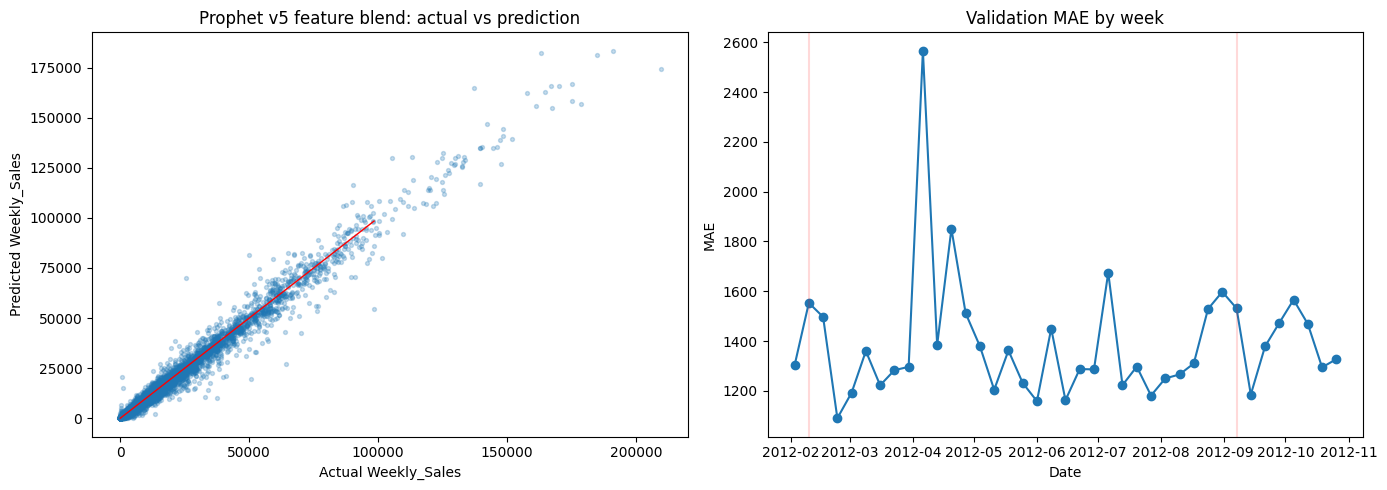

{'validation/wmae': 1415.5391814906354,
 'validation/mae': 1389.494560286699,
 'validation/raw_prophet_wmae': 1654.663476829436,
 'validation/seasonal_naive_wmae': 1604.2696976819943,
 'validation/improvement_vs_seasonal_naive_pct': 11.764263606303555,
 'validation/improvement_vs_raw_prophet_pct': 14.451536441536483,
 'fit/series_total': 3331,
 'fit/series_fit_ok': 3259,
 'fit/series_fallback': 72,
 'fit/elapsed_minutes': 10.046839765707652}

In [10]:
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group=CONFIG["wandb_group"],
    name=CONFIG["run_name"],
    job_type="experiment_train",
    tags=["prophet", "classical-statistical", "experiment", "event-aware-holidays", "clean-covariates", "markdown", "all-series", "wmae"],
    config={**CONFIG, **split_summary},
    save_code=True,
)

val_pred_path = OUTPUT_DIR / "prophet_v5_validation_predictions.csv"
series_info_path = OUTPUT_DIR / "prophet_v5_series_info.csv"
metrics_path = OUTPUT_DIR / "prophet_v5_metrics.json"
config_path = OUTPUT_DIR / "prophet_v5_config.json"
covariates_path = OUTPUT_DIR / "prophet_v5_store_covariates.csv"

val_pred_df.to_csv(val_pred_path, index=False)
series_info_df.to_csv(series_info_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **split_summary}, indent=2))
store_covariates.to_csv(covariates_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = val_pred_df.sample(min(8000, len(val_pred_df)), random_state=SEED)
axes[0].scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
axes[0].plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
axes[0].set_title("Prophet v5 feature blend: actual vs prediction")
axes[0].set_xlabel("Actual Weekly_Sales")
axes[0].set_ylabel("Predicted Weekly_Sales")

weekly_errors = (
    val_pred_df.groupby("Date", as_index=False)
    .agg(Weekly_MAE=("AbsError", "mean"), IsHoliday=("IsHoliday", "max"))
)
axes[1].plot(weekly_errors["Date"], weekly_errors["Weekly_MAE"], marker="o")
for date in weekly_errors.loc[weekly_errors["IsHoliday"], "Date"]:
    axes[1].axvline(date, color="red", alpha=0.15)
axes[1].set_title("Validation MAE by week")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MAE")
plt.tight_layout()
plot_path = OUTPUT_DIR / "prophet_v5_validation_diagnostics.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact(
    CONFIG["artifact_name"],
    type="model-evaluation",
    description="Prophet v5 event-aware, clean-covariate seasonal-naive blend validation outputs.",
    metadata={**CONFIG, **metrics, **split_summary},
)
for artifact_path in [val_pred_path, series_info_path, metrics_path, config_path, covariates_path, plot_path]:
    artifact.add_file(str(artifact_path))
run.log_artifact(artifact, aliases=["v5", "validation", "latest"])

wandb.log({
    **metrics,
    "data/store_covariates": wandb.Table(dataframe=store_covariates.head(5000)),
    "data/holiday_event_calendar": wandb.Table(dataframe=holidays_df),
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/series_info": wandb.Table(dataframe=series_info_df),
    "validation/weekly_errors": wandb.Table(dataframe=weekly_errors),
    "validation/diagnostic_plot": wandb.Image(str(plot_path)),
})
for key, value in metrics.items():
    run.summary[key] = value
run.summary["validation_predictions_path"] = str(val_pred_path)
run.summary["seasonal_naive_wmae"] = float(seasonal_naive_wmae)
run.summary["blend_wmae"] = float(blend_wmae)
run.summary["raw_prophet_wmae"] = float(raw_prophet_wmae)
run.summary["covariate_count"] = int(len(CONFIG["covariate_columns"]))

metrics


## End run

This experiment creates validation evidence only. No Kaggle submission is generated here.

In [11]:
print("Experiment complete. W&B contains clean covariates, event calendar, blend metrics and validation artifacts.")

Experiment complete. W&B contains clean covariates, event calendar, blend metrics and validation artifacts.


In [12]:
wandb.finish()


fit/elapsed_minutes,▁
fit/series_fallback,▁
fit/series_fit_ok,▁
fit/series_total,▁
validation/improvement_vs_raw_prophet_pct,▁
validation/improvement_vs_seasonal_naive_pct,▁
validation/mae,▁
validation/raw_prophet_wmae,▁
validation/seasonal_naive_wmae,▁
validation/wmae,▁
blend_wmae,1415.53918
